In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index

# ── Load clean training data ───────────────────────────
train = pd.read_csv('data/clean/train.csv')
test  = pd.read_csv('data/clean/test.csv')

print("Train shape:", train.shape)
print("Test shape: ", test.shape)
print("\nColumns:", list(train.columns))


Train shape: (400, 17)
Test shape:  (100, 17)

Columns: ['age', 'donor_age', 'hla_mismatch', 'cold_ischemia_hours', 'pra', 'dialysis_years', 'living_donor', 'egfr_1year', 'delayed_graft_function', 'donor_hypertension', 'donor_risk_index', 'immune_risk_score', 'age_group', 'ischemia_risk', 'egfr_category', 'duration_years', 'graft_failure']


In [2]:
# ── Train Cox Proportional Hazards Model ───────────────
cph = CoxPHFitter(penalizer=0.1)

cph.fit(
    train,
    duration_col='duration_years',
    event_col='graft_failure'
)

print("✅ Model trained!")
print("\n=== MODEL SUMMARY ===")
cph.print_summary()

✅ Model trained!

=== MODEL SUMMARY ===


<lifelines.CoxPHFitter: fitted with 400 total observations, 187 right-censored observations>
             duration col = 'duration_years'
                event col = 'graft_failure'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 400
number of events observed = 213
   partial log-likelihood = -925.18
         time fit was run = 2026-03-20 04:20:25 UTC

---
                        coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                               
age                     0.59      1.80      0.11            0.37            0.81                1.45                2.25
donor_age               0.44      1.56      0.07            0.31            0.58                1.36                1.79
hla_mismatch            0.48      1.61      0.10            0.27            0.68                1.31                1.98
cold_ischemia_hours     0.38      1.46      0.10            0.17            0.58                1.19                1.79
pra                     0.21      1.24      0.09            0.04            0.39                1.04                1.48
dialysis_years          0.49      1.64      0.07            0.36            0.62                1.44                1.87
living_donor           -0.51      0.60      0.07           -0.66           -0.37                0.52                0.69
egfr_1year             -0.59      0.56      0.11           -0.81           -0.37                0.45                0.69
delayed_graft_function  0.35      1.42      0.07            0.22            0.48                1.25                1.61
donor_hypertension      0.15      1.16      0.11           -0.08            0.37                0.93                1.45
donor_risk_index        0.27      1.31      0.12            0.04            0.50                1.05                1.65
immune_risk_score       0.53      1.71      0.12            0.30            0.77                1.35                2.15
age_group               0.27      1.32      0.11            0.06            0.49                1.06                1.63
ischemia_risk           0.16      1.17      0.10           -0.04            0.35                0.96                1.43
egfr_category          -0.16      0.85      0.11           -0.36            0.05                0.70                1.05

                        cmp to     z      p  -log2(p)
covariate                                            
age                       0.00  5.24 <0.005     22.59
donor_age                 0.00  6.30 <0.005     31.63
hla_mismatch              0.00  4.56 <0.005     17.58
cold_ischemia_hours       0.00  3.60 <0.005     11.64
pra                       0.00  2.37   0.02      5.83
dialysis_years            0.00  7.36 <0.005     42.33
living_donor              0.00 -7.01 <0.005     38.65
egfr_1year                0.00 -5.29 <0.005     22.95
delayed_graft_function    0.00  5.29 <0.005     22.95
donor_hypertension        0.00  1.30   0.19      2.37
donor_risk_index          0.00  2.34   0.02      5.70
immune_risk_score         0.00  4.52 <0.005     17.30
age_group                 0.00  2.51   0.01      6.37
ischemia_risk             0.00  1.55   0.12      3.04
egfr_category             0.00 -1.50   0.13      2.91
---
Concordance = 0.92
Partial AIC = 1880.35
log-likelihood ratio test = 431.36 on 15 df
-log2(p) of ll-ratio test = 271.59

✅ Model saved to models/cox_model.pkl


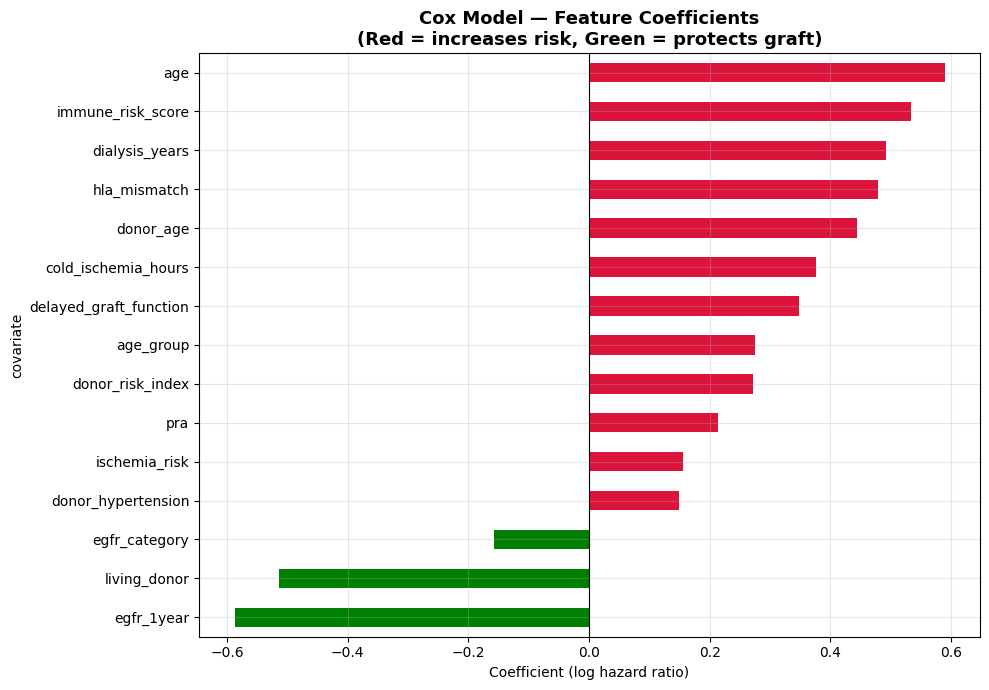

✅ Chart saved


In [3]:
# ── Save the model ─────────────────────────────────────
joblib.dump(cph, 'models/cox_model.pkl')
print("✅ Model saved to models/cox_model.pkl")

# ── Feature importance plot ────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

coefs = cph.params_.sort_values()
colors = ['green' if c < 0 else 'crimson' for c in coefs]

coefs.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Cox Model — Feature Coefficients\n(Red = increases risk, Green = protects graft)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Coefficient (log hazard ratio)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('notebooks/feature_importance_day4.png', dpi=150)
plt.show()
print("✅ Chart saved")